# Student Team Compatibility Classifier
Machine Learning pipeline- data generation, impurity injection, preprocessing, clustering, and classification using KNN and Decision Trees.

## Importing Libraries & Configuration

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split, cross_val_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110

## 1. Dataset Generation
Generating a 5000-row synthetic dataset representing 5 student personas.

In [49]:
print("  STUDENT TEAM COMPATIBILITY CLASSIFIER")
print("\n[1/10] Generating 5000-row synthetic dataset...")

np.random.seed(42)
PERSONA_CONFIGS = {
    "Night-Owl Hustler": dict(
        n=1000, late_night=5, in_person=2, stress=5,
        target=5, role=5, skill=3, pacing=5
    ),
    "Balanced Socializer": dict(
        n=1000, late_night=1, in_person=5, stress=2,
        target=3, role=2, skill=2, pacing=2
    ),
    "Structured Achiever": dict(
        n=1000, late_night=3, in_person=4, stress=3,
        target=5, role=3, skill=5, pacing=2
    ),
    "Solo Coder": dict(
        n=1000, late_night=4, in_person=1, stress=1,
        target=2, role=1, skill=2, pacing=5
    ),
    "Relaxed Collaborator": dict(
        n=1000, late_night=2, in_person=3, stress=2,
        target=2, role=2, skill=4, pacing=1
    ),
}

FEATURES = [
    'Late_Night_Pref', 'In_Person_Pref', 'Stress_Level',
    'Target_Grade', 'Role_Pref', 'Skill_Diversity', 'Pacing'
]


def generate_persona(config):
    centers = [
        config['late_night'], config['in_person'], config['stress'],
        config['target'], config['role'], config['skill'], config['pacing']
    ]
    data = {}
    for feature, center in zip(FEATURES, centers):
        raw = np.random.normal(center, 0.9, config['n'])
        data[feature] = np.clip(np.round(raw), 1, 5).astype(int)
    return pd.DataFrame(data)


frames = [generate_persona(cfg) for cfg in PERSONA_CONFIGS.values()]
df_clean = pd.concat(frames).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"    Dataset shape    : {df_clean.shape}")
print(f"    Features         : {FEATURES}")



  STUDENT TEAM COMPATIBILITY CLASSIFIER

[1/10] Generating 5000-row synthetic dataset...
    Dataset shape    : (5000, 7)
    Features         : ['Late_Night_Pref', 'In_Person_Pref', 'Stress_Level', 'Target_Grade', 'Role_Pref', 'Skill_Diversity', 'Pacing']


## 2. Injecting Data Impurities
Make clean dataset dirty to make it real-world  data  such as missing values, out-of-range values, duplicates rows , inconsistent types, noise/garbage text, and extreme outliers.

Impurity Types Injected:
  A) Missing Values     — NaN in random cells (~5% of data)

  B) Out-of-Range Values — scores like 0, 6, 7, -1 (invalid on 1-5 scale)

  C) Duplicate Rows     — 200 exact duplicate entries

  D) Inconsistent Types — numeric columns stored as strings ("3", "5.0")

  E) Noisy/Garbage Text — placeholder strings like "N/A", "?", "unknown"
  
  F) Extreme Outliers   — a few rows with absurdly large values (50, 99)

In [50]:
print("\n[2/10] Inserting realistic data impurities...")

df_dirty = df_clean.copy()
rng = np.random.default_rng(seed=7)

total_cells = df_dirty.shape[0] * len(FEATURES)

n_missing = int(total_cells * 0.05)
missing_rows = rng.integers(0, df_dirty.shape[0], n_missing)
missing_cols = rng.choice(FEATURES, n_missing)
for r, c in zip(missing_rows, missing_cols):
    df_dirty.at[r, c] = np.nan
print(f"    A) Missing values injected      : {df_dirty.isnull().sum().sum()} NaNs")

n_oor = 300
oor_rows = rng.integers(0, df_dirty.shape[0], n_oor)
oor_cols = rng.choice(FEATURES, n_oor)
oor_vals = rng.choice([0, 6, 7, -1, 8, 10], n_oor)
for r, c, v in zip(oor_rows, oor_cols, oor_vals):
    df_dirty.at[r, c] = v
print(f"    B) Out-of-range values injected : {n_oor} cells")

dup_indices = rng.choice(df_dirty.index, 200, replace=False)
dup_rows    = df_dirty.loc[dup_indices]
df_dirty    = pd.concat([df_dirty, dup_rows], ignore_index=True)
print(f"    C) Duplicate rows injected      : 200 rows → total shape {df_dirty.shape}")

n_str = 400
str_rows = rng.integers(0, df_dirty.shape[0], n_str)
str_cols = rng.choice(FEATURES, n_str)
for r, c in zip(str_rows, str_cols):
    val = df_dirty.at[r, c]
    if pd.notna(val):
        style = rng.integers(0, 3)
        if style == 0:
            df_dirty.at[r, c] = str(int(val)) if not isinstance(val, str) else val
        elif style == 1:
            df_dirty.at[r, c] = f"{float(val):.1f}" if not isinstance(val, str) else val
        else:
            df_dirty.at[r, c] = f" {int(val)} " if not isinstance(val, str) else val
print(f"    D) String-typed cells injected  : {n_str} cells")

garbage_values = ["N/A", "?", "unknown", "n/a", "--", "NA", "none"]
n_garbage = 150
garb_rows = rng.integers(0, df_dirty.shape[0], n_garbage)
garb_cols = rng.choice(FEATURES, n_garbage)
garb_vals = rng.choice(garbage_values, n_garbage)
for r, c, v in zip(garb_rows, garb_cols, garb_vals):
    df_dirty.at[r, c] = v
print(f"    E) Garbage text injected        : {n_garbage} cells")

n_outliers = 80
out_rows = rng.integers(0, df_dirty.shape[0], n_outliers)
out_cols = rng.choice(FEATURES, n_outliers)
out_vals = rng.choice([50, 75, 99, 100, -50, -10], n_outliers)
for r, c, v in zip(out_rows, out_cols, out_vals):
    df_dirty.at[r, c] = v
print(f"    F) Extreme outliers injected    : {n_outliers} cells")

df_dirty.to_csv('student_survey_dirty.csv', index=False)
print(f"\n    Dirty dataset shape : {df_dirty.shape}")
print(f"    Saved to            : student_survey_dirty.csv")


print("\n    Dirty Data Summary ")
print(f"    Total rows          : {df_dirty.shape[0]}")
print(f"    Duplicate rows      : {df_dirty.duplicated().sum()}")
print(f"    Missing values (NaN): {df_dirty.isnull().sum().sum()}")
print(f"    Dtypes (all mixed)  : {df_dirty.dtypes.unique().tolist()}")




[2/10] Inserting realistic data impurities...
    A) Missing values injected      : 1704 NaNs
    B) Out-of-range values injected : 300 cells
    C) Duplicate rows injected      : 200 rows → total shape (5200, 7)
    D) String-typed cells injected  : 400 cells
    E) Garbage text injected        : 150 cells
    F) Extreme outliers injected    : 80 cells

    Dirty dataset shape : (5200, 7)
    Saved to            : student_survey_dirty.csv

    Dirty Data Summary 
    Total rows          : 5200
    Duplicate rows      : 1078
    Missing values (NaN): 1743
    Dtypes (all mixed)  : [dtype('O')]


## 3. Data Preprocessing (Cleaning Pipeline)
 Data cleaning pipeline to fix all impurities inserted in the previous step.
 Steps:
  3.1  Remove exact duplicate rows

  3.2  Replace garbage strings → NaN

  3.3  Coerce all columns to numeric (type correction)

  3.4  Clip out-of-range & extreme outliers to valid range [1, 5]

  3.5  Impute remaining NaNs with column median

  3.6  Round & cast to integer (survey scores must be whole numbers)
  
  3.7  Final validation check

In [51]:
print("\n[3/10] Preprocessing pipeline — cleaning dirty data")

df_proc = df_dirty.copy()

before = df_proc.shape[0]
df_proc.drop_duplicates(inplace=True)
df_proc.reset_index(drop=True, inplace=True)
print(f"    3.1  Duplicates removed        : {before - df_proc.shape[0]} rows  "
      f"(remaining: {df_proc.shape[0]})")

GARBAGE_TOKENS = {"n/a", "na", "?", "unknown", "--", "none", ""}
for col in FEATURES:
    df_proc[col] = df_proc[col].apply(
        lambda x: np.nan if isinstance(x, str) and x.strip().lower() in GARBAGE_TOKENS else x
    )
print(f"    3.2  Garbage strings → NaN     : done  "
      f"(NaN count now: {df_proc.isnull().sum().sum()})")

for col in FEATURES:
    df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')
print(f"    3.3  Type coercion to numeric  : done  "
      f"(NaN count after coercion: {df_proc.isnull().sum().sum()})")


before_oor = ((df_proc[FEATURES] < 1) | (df_proc[FEATURES] > 5)).sum().sum()
df_proc[FEATURES] = df_proc[FEATURES].clip(lower=1, upper=5)
print(f"    3.4  Out-of-range values clipped: {before_oor} cells clipped to [1, 5]")

nan_before = df_proc.isnull().sum().sum()
for col in FEATURES:
    median_val = df_proc[col].median()
    df_proc[col].fillna(median_val, inplace=True)
print(f"    3.5  NaN imputation (median)   : {nan_before} NaNs filled")

df_proc[FEATURES] = df_proc[FEATURES].round(0).astype(int)
print(f"    3.6  Rounded & cast to int     : done")

before_final_dedup = df_proc.shape[0]
df_proc.drop_duplicates(inplace=True)
df_proc.reset_index(drop=True, inplace=True)
print(f"    3.7  Post-normalization duplicates removed: {before_final_dedup - df_proc.shape[0]} rows")

assert df_proc[FEATURES].isnull().sum().sum() == 0, "NaNs still present!"
assert ((df_proc[FEATURES] < 1) | (df_proc[FEATURES] > 5)).sum().sum() == 0, "OOR values remain!"
assert df_proc.duplicated().sum() == 0, "Duplicates still present!"

df_proc.to_csv('student_survey_clean.csv', index=False)

print(f"\n  Post-Preprocessing Summary ")
print(f"    Final dataset shape : {df_proc.shape}")
print(f"    Missing values      : {df_proc.isnull().sum().sum()}")
print(f"    Duplicates          : {df_proc.duplicated().sum()}")
print(f"    Value range check   : all features in [1, 5] ✓")
print(f"    Saved to            : student_survey_clean.csv")




[3/10] Preprocessing pipeline — cleaning dirty data
    3.1  Duplicates removed        : 1078 rows  (remaining: 4122)
    3.2  Garbage strings → NaN     : done  (NaN count now: 1771)
    3.3  Type coercion to numeric  : done  (NaN count after coercion: 1771)
    3.4  Out-of-range values clipped: 377 cells clipped to [1, 5]
    3.5  NaN imputation (median)   : 1771 NaNs filled
    3.6  Rounded & cast to int     : done
    3.7  Post-normalization duplicates removed: 662 rows

  Post-Preprocessing Summary 
    Final dataset shape : (3460, 7)
    Missing values      : 0
    Duplicates          : 0
    Value range check   : all features in [1, 5] ✓
    Saved to            : student_survey_clean.csv


### Preprocessing Report Visualization
Visualizing the data before and after cleaning.

Preprocessing Report — Before vs Afte

Missing Value count, total dataset size, feature value ditribution ,

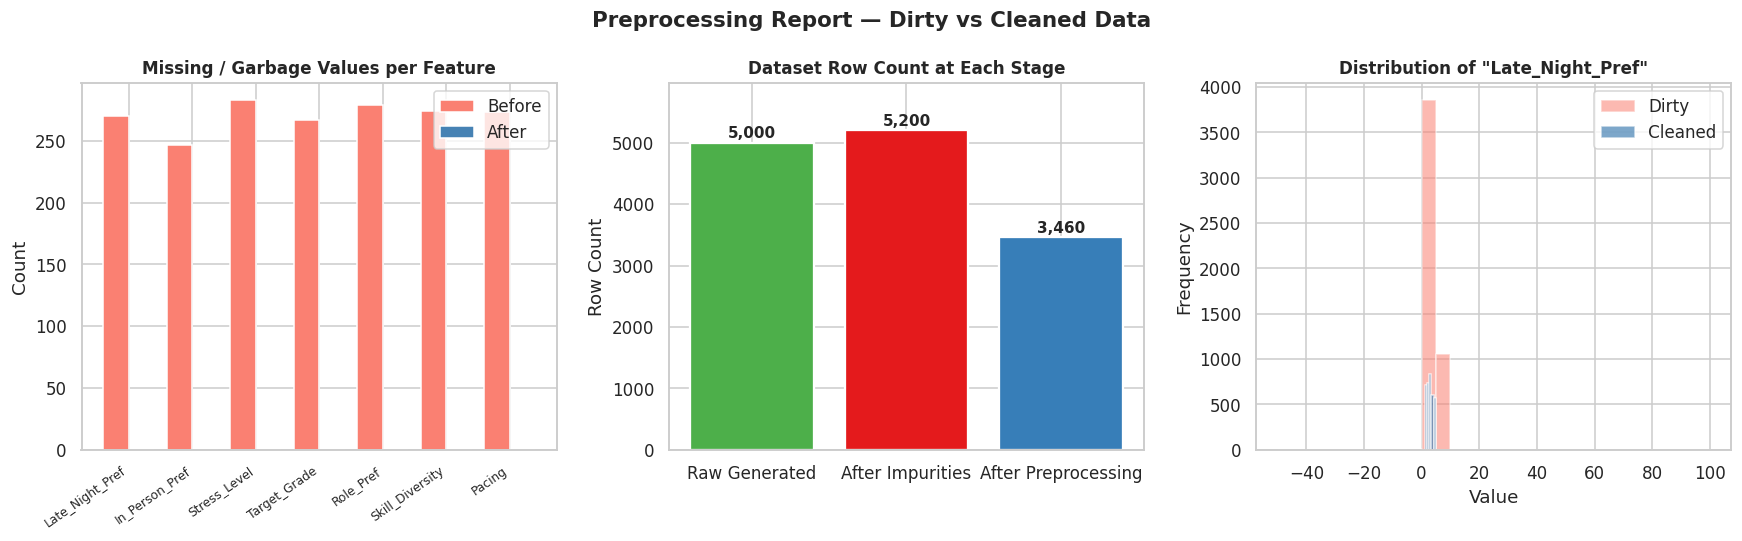


    Saved: plot0_preprocessing_report.png


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Preprocessing Report — Dirty vs Cleaned Data', fontsize=14, fontweight='bold')

nan_before_col = df_dirty[FEATURES].apply(
    lambda col: col.apply(lambda x: pd.isna(x) or (isinstance(x, str) and x.strip().lower() in GARBAGE_TOKENS))
).sum()
nan_after_col = df_proc[FEATURES].isnull().sum()

x = np.arange(len(FEATURES))
axes[0].bar(x - 0.2, nan_before_col, 0.4, label='Before', color='salmon')
axes[0].bar(x + 0.2, nan_after_col,  0.4, label='After',  color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(FEATURES, rotation=35, ha='right', fontsize=8)
axes[0].set_title('Missing / Garbage Values per Feature', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()


stages   = ['Raw Generated', 'After Impurities', 'After Preprocessing']
sizes    = [df_clean.shape[0], df_dirty.shape[0], df_proc.shape[0]]
colors_b = ['#4daf4a', '#e41a1c', '#377eb8']
bars = axes[1].bar(stages, sizes, color=colors_b, edgecolor='white', linewidth=1.5)
for bar, sz in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{sz:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Dataset Row Count at Each Stage', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Row Count')
axes[1].set_ylim(0, max(sizes) * 1.15)


sample_col = 'Late_Night_Pref'
dirty_numeric = pd.to_numeric(df_dirty[sample_col], errors='coerce')
axes[2].hist(dirty_numeric.dropna(), bins=30, alpha=0.55, color='salmon',
             label='Dirty', edgecolor='white')
axes[2].hist(df_proc[sample_col], bins=5, alpha=0.7, color='steelblue',
             label='Cleaned', edgecolor='white')
axes[2].set_title(f'Distribution of "{sample_col}"', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot0_preprocessing_report.png', bbox_inches='tight')
plt.show()
print("\n    Saved: plot0_preprocessing_report.png")

X = df_proc[FEATURES].values


## 4. Feature Scaling
Scaling features using StandardScaler so all features have mean=0 and std=1.

In [53]:
print("\n[4/10] Scaling features with StandardScaler...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("    All features scaled to mean=0, std=1")


[4/10] Scaling features with StandardScaler...
    All features scaled to mean=0, std=1


## 5. Elbow Method for Optimal K
Running the Elbow Method to determine the optimal number of clusters for K-Means.


[5/10] Running Elbow Method to find optimal K for K-Means...


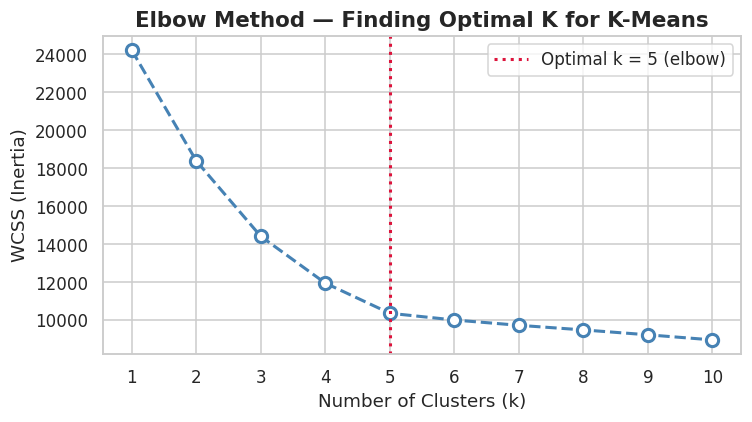

    Saved: plot1_elbow_curve.png


In [54]:
print("\n[5/10] Running Elbow Method to find optimal K for K-Means...")

MAX_K = 10
wcss = []

for k in range(1, MAX_K + 1):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, MAX_K + 1), wcss, marker='o', linestyle='--',
        color='steelblue', linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.axvline(x=5, color='crimson', linestyle=':', linewidth=2, label='Optimal k = 5 (elbow)')
ax.set_title('Elbow Method — Finding Optimal K for K-Means', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('WCSS (Inertia)', fontsize=12)
ax.set_xticks(range(1, MAX_K + 1))
ax.legend()
plt.tight_layout()
plt.savefig('plot1_elbow_curve.png', bbox_inches='tight')
plt.show()
print("    Saved: plot1_elbow_curve.png")


## 6. K-Means Clustering (Ground Truth Labels)
Fitting K-Means (k=5) to generate ground-truth labels for our student personas.

In [55]:
print("\n[6/10] Fitting K-Means (k=5) to generate ground-truth labels...")

OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init='auto')
y_labels = kmeans.fit_predict(X_scaled)

unique, counts = np.unique(y_labels, return_counts=True)
print("    Cluster distribution:")
for cluster, count in zip(unique, counts):
    print(f"      Cluster {cluster}: {count} students")



[6/10] Fitting K-Means (k=5) to generate ground-truth labels...
    Cluster distribution:
      Cluster 0: 791 students
      Cluster 1: 752 students
      Cluster 2: 592 students
      Cluster 3: 757 students
      Cluster 4: 568 students


## 7. Train / Test Split
Splitting the data into 70% training and 30% testing sets.

In [56]:
print("\n[7/10] Splitting data — 70% train / 30% test...")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)

print(f"    Training samples : {len(X_train)}")
print(f"    Testing samples  : {len(X_test)}")



[7/10] Splitting data — 70% train / 30% test...
    Training samples : 2422
    Testing samples  : 1038


## 8. PCA (7D → 2D Visualization)
Applying Principal Component Analysis to reduce our 7 features down to 2 dimensions for easier visualization.

In [57]:
print("\n[8/10] Applying PCA (7D → 2D) for visualization...")

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

var_explained = pca.explained_variance_ratio_ * 100
print(f"    PC1 explains: {var_explained[0]:.1f}% of variance")
print(f"    PC2 explains: {var_explained[1]:.1f}% of variance")
print(f"    Combined    : {sum(var_explained):.1f}% of variance captured")



[8/10] Applying PCA (7D → 2D) for visualization...
    PC1 explains: 34.0% of variance
    PC2 explains: 25.5% of variance
    Combined    : 59.5% of variance captured


## 9. KNN & Decision Tree Training & Cross-Validation
Finding optimal hyperparameters via Cross-Validation and training our final models.


[9/10] Finding optimal hyperparameters via Cross-Validation...
    Best k for KNN          : 27  (CV Accuracy: 97.52%)


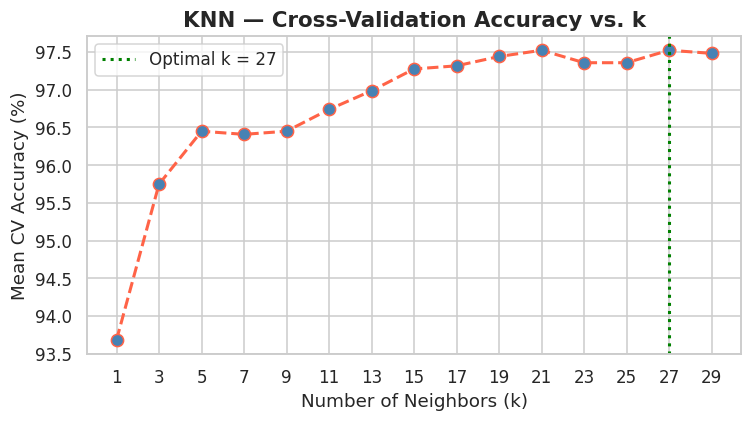

    Saved: plot2_knn_cross_validation.png
    Best max_depth for DT   : 11  (CV Accuracy: 92.61%)


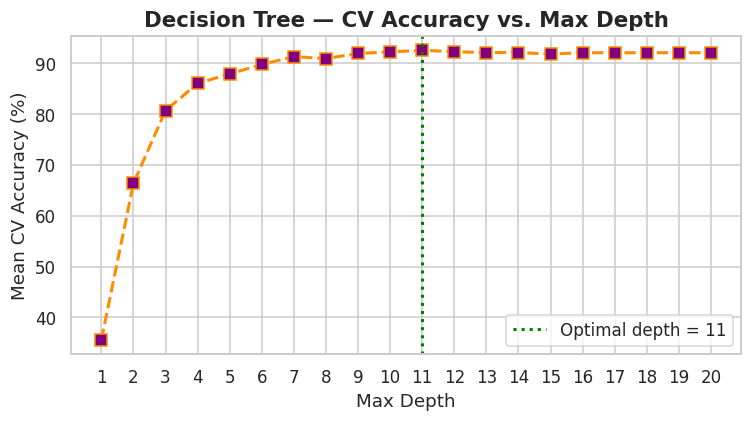

    Saved: plot3_dt_cross_validation.png

      Training final models and evaluating on test data...

  ──────────────────────────────────────────────────
  Model        : K-Nearest Neighbors (k=27)
  Accuracy     : 98.46%
  F1-Score     : 98.46%  (weighted)

  Classification Report:
                  precision    recall  f1-score   support
    
       Cluster 0       0.98      0.99      0.99       237
       Cluster 1       0.97      0.99      0.98       226
       Cluster 2       0.99      0.99      0.99       178
       Cluster 3       0.99      0.97      0.98       227
       Cluster 4       1.00      0.98      0.99       170
    
        accuracy                           0.98      1038
       macro avg       0.99      0.98      0.99      1038
    weighted avg       0.98      0.98      0.98      1038
    
  ──────────────────────────────────────────────────
  Model        : Decision Tree (max_depth=11)
  Accuracy     : 93.93%
  F1-Score     : 93.91%  (weighted)

  Classification R

In [58]:
print("\n[9/10] Finding optimal hyperparameters via Cross-Validation...")

k_values = list(range(1, 30, 2))
cv_scores_knn = []

for k in k_values:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_knn.append(scores.mean())

optimal_knn_k = k_values[np.argmax(cv_scores_knn)]
print(f"    Best k for KNN          : {optimal_knn_k}  "
      f"(CV Accuracy: {max(cv_scores_knn)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, [s * 100 for s in cv_scores_knn],
        marker='o', linestyle='dashed', color='tomato',
        markerfacecolor='steelblue', markersize=8, linewidth=2)
ax.axvline(x=optimal_knn_k, color='green', linestyle=':', linewidth=2,
           label=f'Optimal k = {optimal_knn_k}')
ax.set_title('KNN — Cross-Validation Accuracy vs. k', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Neighbors (k)', fontsize=12)
ax.set_ylabel('Mean CV Accuracy (%)', fontsize=12)
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.savefig('plot2_knn_cross_validation.png', bbox_inches='tight')
plt.show()
print("    Saved: plot2_knn_cross_validation.png")



depths = list(range(1, 21))
cv_scores_dt = []

for depth in depths:
    dt_cv = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_dt.append(scores.mean())

optimal_depth = depths[np.argmax(cv_scores_dt)]
print(f"    Best max_depth for DT   : {optimal_depth}  "
      f"(CV Accuracy: {max(cv_scores_dt)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, [s * 100 for s in cv_scores_dt],
        marker='s', linestyle='dashed', color='darkorange',
        markerfacecolor='purple', markersize=8, linewidth=2)
ax.axvline(x=optimal_depth, color='green', linestyle=':', linewidth=2,
           label=f'Optimal depth = {optimal_depth}')
ax.set_title('Decision Tree — CV Accuracy vs. Max Depth', fontsize=14, fontweight='bold')
ax.set_xlabel('Max Depth', fontsize=12)
ax.set_ylabel('Mean CV Accuracy (%)', fontsize=12)
ax.set_xticks(depths)
ax.legend()
plt.tight_layout()
plt.savefig('plot3_dt_cross_validation.png', bbox_inches='tight')
plt.show()
print("    Saved: plot3_dt_cross_validation.png")



print("\n      Training final models and evaluating on test data...\n")

knn = KNeighborsClassifier(n_neighbors=optimal_knn_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

dt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) * 100
    f1  = f1_score(y_true, y_pred, average='weighted') * 100
    print(f"  {'─'*50}")
    print(f"  Model        : {name}")
    print(f"  Accuracy     : {acc:.2f}%")
    print(f"  F1-Score     : {f1:.2f}%  (weighted)")
    print(f"\n  Classification Report:")
    report = classification_report(
        y_true, y_pred,
        target_names=[f"Cluster {i}" for i in range(OPTIMAL_K)]
    )
    for line in report.split('\n'):
        print(f"    {line}")
    return acc, f1

acc_knn, f1_knn = evaluate_model(
    f"K-Nearest Neighbors (k={optimal_knn_k})", y_test, y_pred_knn
)
acc_dt, f1_dt = evaluate_model(
    f"Decision Tree (max_depth={optimal_depth})", y_test, y_pred_dt
)
print(f"  {'─'*50}\n")



## 10. Visualizations
Generating various visualizations to evaluate model performance.

### Decision Boundaries
Visualizing decision boundaries on the PCA-reduced test data.

[10/10] Generating final visualizations...



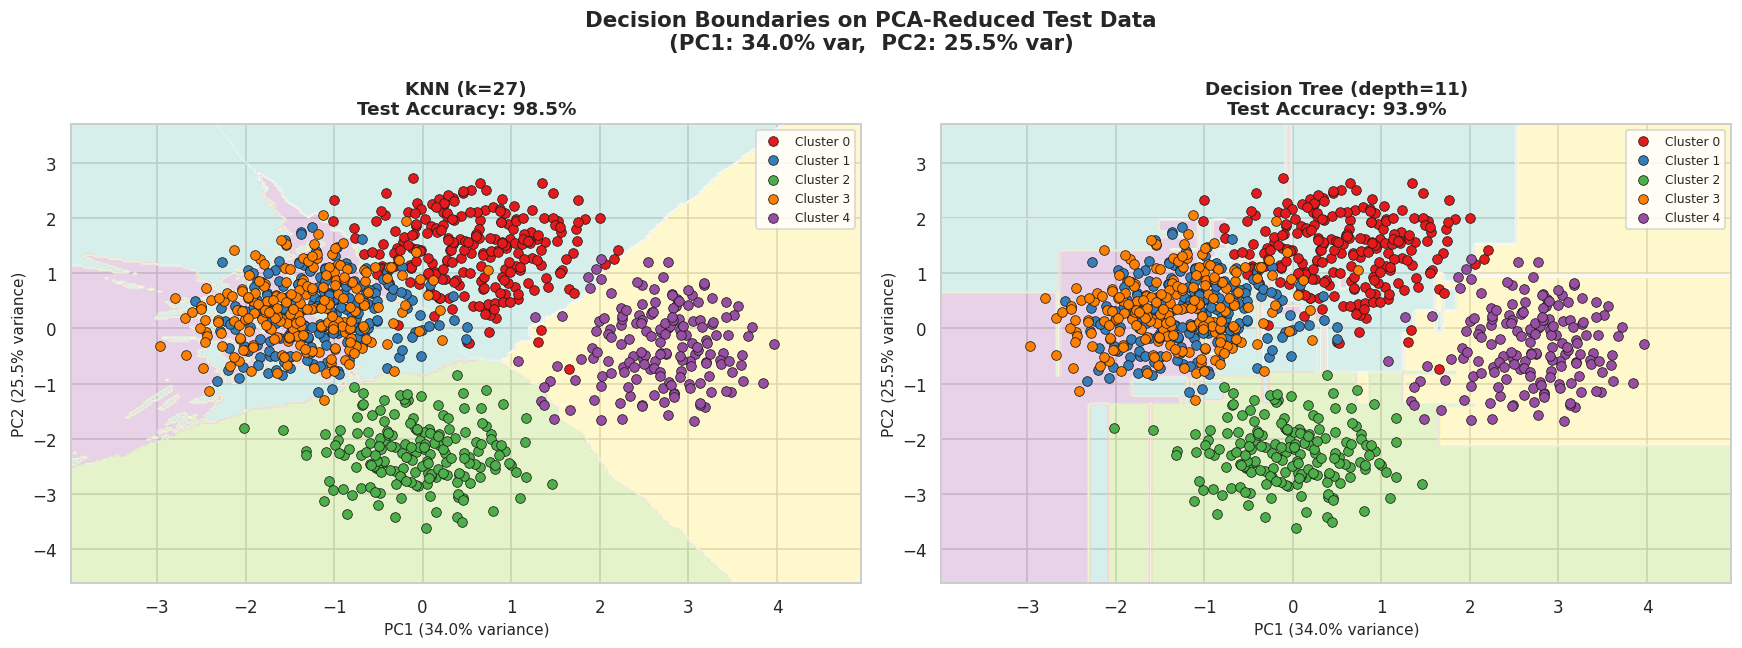

    Saved: plot4_decision_boundaries.png


In [59]:
print("[10/10] Generating final visualizations...\n")

CLUSTER_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']
CLUSTER_NAMES  = [f"Cluster {i}" for i in range(OPTIMAL_K)]


def make_mesh(X_pca, h=0.04):
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Decision Boundaries on PCA-Reduced Test Data\n'
    f'(PC1: {var_explained[0]:.1f}% var,  PC2: {var_explained[1]:.1f}% var)',
    fontsize=14, fontweight='bold'
)

knn_pca = KNeighborsClassifier(n_neighbors=optimal_knn_k)
knn_pca.fit(X_train_pca, y_train)

dt_pca = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt_pca.fit(X_train_pca, y_train)

plot_models = [
    (knn_pca, f"KNN (k={optimal_knn_k})\nTest Accuracy: {acc_knn:.1f}%"),
    (dt_pca,  f"Decision Tree (depth={optimal_depth})\nTest Accuracy: {acc_dt:.1f}%"),
]

xx, yy = make_mesh(X_test_pca)
cmap_bg = plt.cm.get_cmap('Set3', OPTIMAL_K)

for ax, (model_pca, title) in zip(axes, plot_models):
    Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.5, alpha=0.6)
    for cluster_id in range(OPTIMAL_K):
        mask = y_test == cluster_id
        ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                   c=CLUSTER_COLORS[cluster_id], edgecolors='k',
                   s=40, linewidths=0.5, label=f'Cluster {cluster_id}', zorder=3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)', fontsize=10)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig('plot4_decision_boundaries.png', bbox_inches='tight')
plt.show()
print("    Saved: plot4_decision_boundaries.png")


### Confusion Matrices
Evaluating test set predictions with confusion matrices.

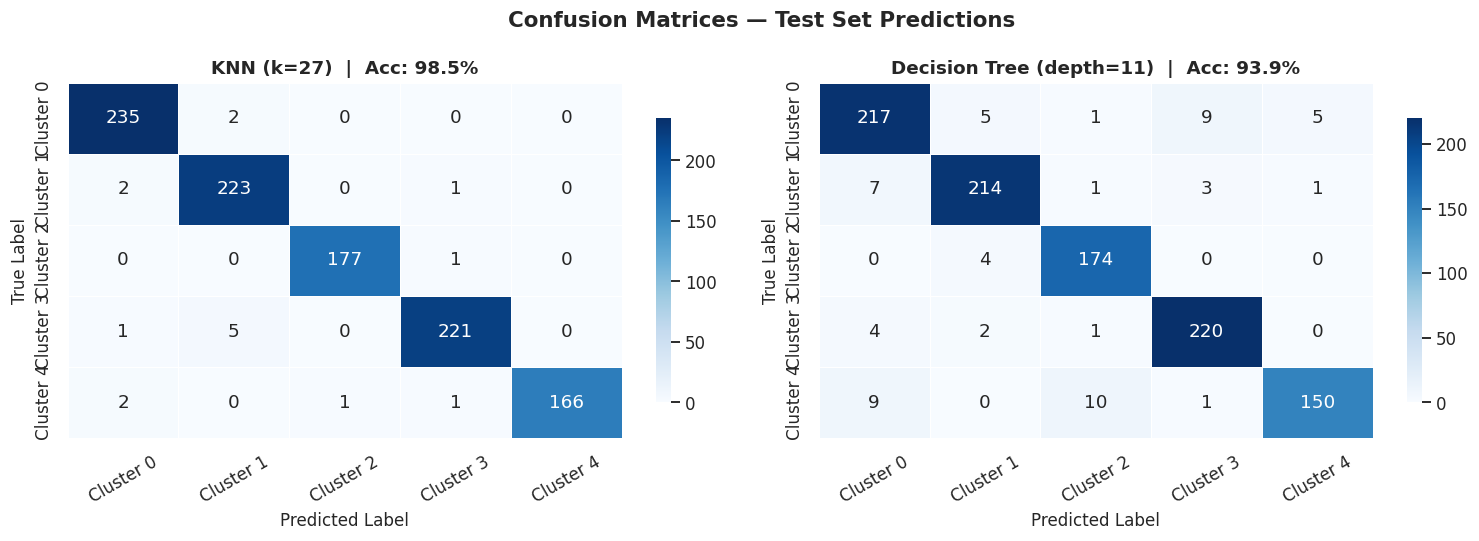

    Saved: plot5_confusion_matrices.png


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Test Set Predictions', fontsize=14, fontweight='bold')

cm_data = [
    (confusion_matrix(y_test, y_pred_knn), f"KNN (k={optimal_knn_k})  |  Acc: {acc_knn:.1f}%"),
    (confusion_matrix(y_test, y_pred_dt),  f"Decision Tree (depth={optimal_depth})  |  Acc: {acc_dt:.1f}%"),
]

for ax, (cm, title) in zip(axes, cm_data):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLUSTER_NAMES, yticklabels=CLUSTER_NAMES,
                linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot5_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("    Saved: plot5_confusion_matrices.png")


### Model Comparison
Comparing KNN and Decision Tree models by Accuracy and F1-Score.

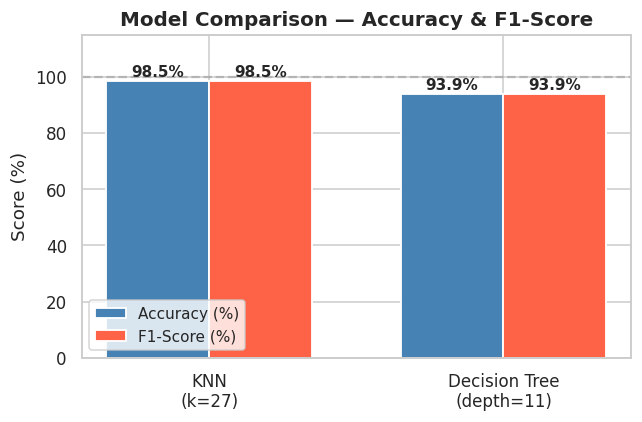

    Saved: plot6_model_comparison.png


In [67]:
fig, ax = plt.subplots(figsize=(6, 4))
model_names = [f'KNN\n(k={optimal_knn_k})', f'Decision Tree\n(depth={optimal_depth})']
x = np.arange(len(model_names))
width = 0.35
bars1 = ax.bar(x - width/2, [acc_knn, acc_dt], width, label='Accuracy (%)',
               color='steelblue', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, [f1_knn, f1_dt],   width, label='F1-Score (%)',
               color='tomato',   edgecolor='white', linewidth=1.2)
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Model Comparison — Accuracy & F1-Score', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 115)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot6_model_comparison.png', bbox_inches='tight')
plt.show()
print("    Saved: plot6_model_comparison.png")


### Decision Tree Structure
Visualizing the top levels of the trained Decision Tree.

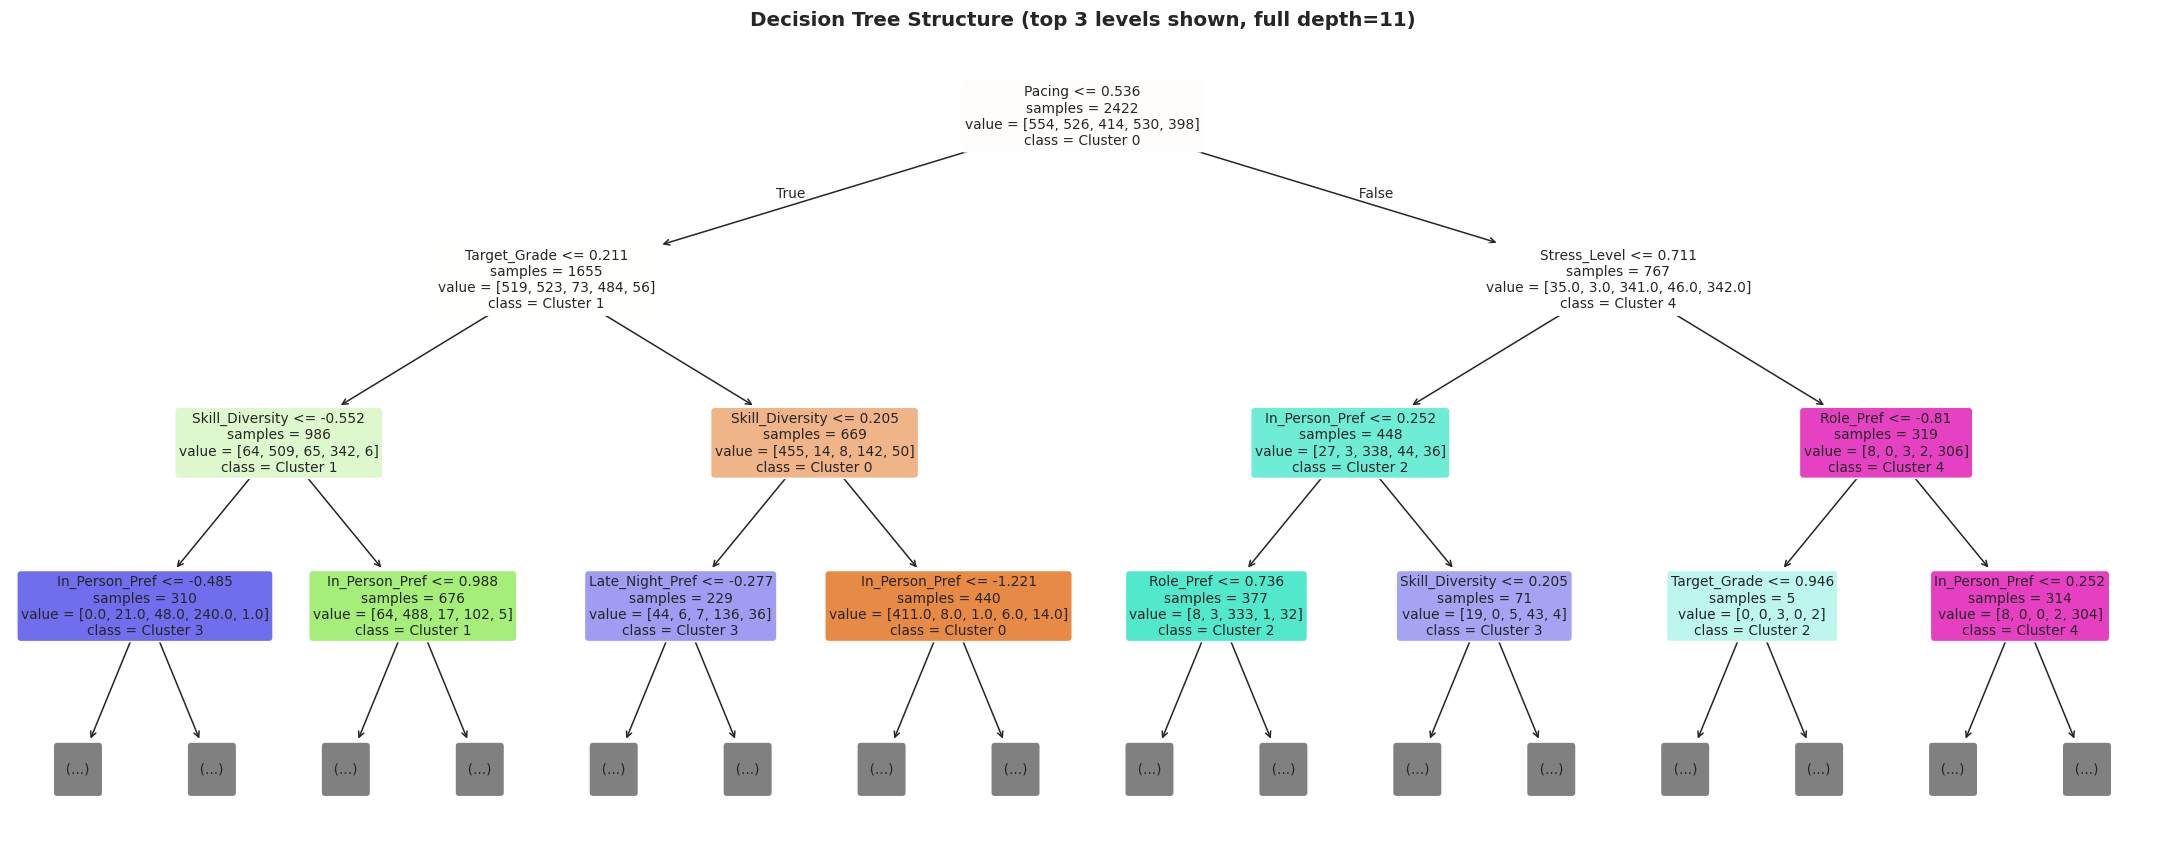

    Saved: plot7_decision_tree_structure.png


In [62]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=FEATURES, class_names=CLUSTER_NAMES,
          filled=True, rounded=True, fontsize=9, ax=ax, impurity=False, proportion=False)
ax.set_title(f'Decision Tree Structure (top 3 levels shown, full depth={optimal_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_decision_tree_structure.png', bbox_inches='tight')
plt.show()
print("    Saved: plot7_decision_tree_structure.png")


### Feature Importance
Extracting feature importance scores from the Decision Tree.

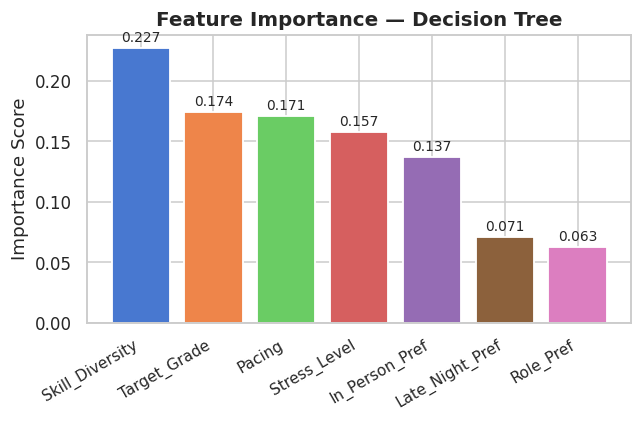

    Saved: plot8_feature_importance.png


In [63]:
importances = dt.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(range(len(FEATURES)), importances[sorted_idx],
              color=sns.color_palette("muted", len(FEATURES)),
              edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i] for i in sorted_idx], rotation=30, ha='right', fontsize=10)
ax.set_title('Feature Importance — Decision Tree', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score', fontsize=12)
for bar, imp in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{imp:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot8_feature_importance.png', bbox_inches='tight')
plt.show()
print("    Saved: plot8_feature_importance.png")


### Cluster Profiles Heatmap
Visualizing the mean feature values for each student persona.

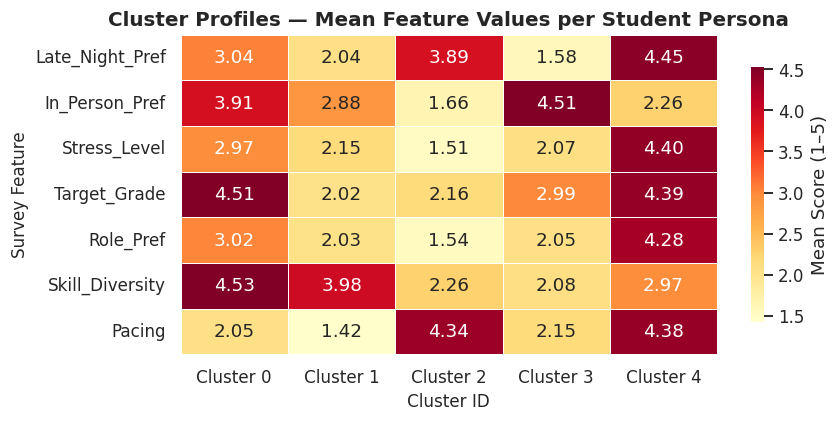

    Saved: plot9_cluster_profiles.png


In [64]:
df_proc['Cluster'] = y_labels
cluster_means = df_proc.groupby('Cluster')[FEATURES].mean().round(2)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Mean Score (1–5)', 'shrink': 0.8}, ax=ax)
ax.set_title('Cluster Profiles — Mean Feature Values per Student Persona',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Survey Feature', fontsize=11)
ax.set_xticklabels([f'Cluster {i}' for i in cluster_means.index], rotation=0)
plt.tight_layout()
plt.savefig('plot9_cluster_profiles.png', bbox_inches='tight')
plt.show()
print("    Saved: plot9_cluster_profiles.png")


## Testing: Predict a New Student's Group
Testing the model on a completely new set of survey responses.

In [65]:
print("  Testing: Predict group for a new student")

new_student = {
    'Late_Night_Pref': 5,
    'In_Person_Pref':  2,
    'Stress_Level':    4,
    'Target_Grade':    5,
    'Role_Pref':       5,
    'Skill_Diversity': 3,
    'Pacing':          5
}

print(f"\n  New student survey responses: {new_student}")
new_X = np.array([[new_student[f] for f in FEATURES]])
new_X_scaled = scaler.transform(new_X)

pred_knn = knn.predict(new_X_scaled)[0]
pred_dt  = dt.predict(new_X_scaled)[0]

print(f"\n  KNN prediction           → Cluster {pred_knn}")
print(f"  Decision Tree prediction → Cluster {pred_dt}")
print(f"\n  Interpretation: This student matches the profile of")
print(f"  Cluster {pred_knn} — best paired with similarly driven,")
print(f"  fast-paced, ambitious team members.\n")



  Testing: Predict group for a new student

  New student survey responses: {'Late_Night_Pref': 5, 'In_Person_Pref': 2, 'Stress_Level': 4, 'Target_Grade': 5, 'Role_Pref': 5, 'Skill_Diversity': 3, 'Pacing': 5}

  KNN prediction           → Cluster 4
  Decision Tree prediction → Cluster 4

  Interpretation: This student matches the profile of
  Cluster 4 — best paired with similarly driven,
  fast-paced, ambitious team members.



## Final Results Summary

In [66]:
print("  FINAL RESULTS SUMMARY")
print(f"  Original dataset size    : 5,000 students")
print(f"  After impurities injected: {df_dirty.shape[0]:,} rows")
print(f"  After preprocessing      : {df_proc.shape[0]:,} rows")
print(f"  Features used            : {len(FEATURES)}")
print(f"  Clusters (K-Means)       : {OPTIMAL_K}")
print(f"  Training / Testing split : 70% / 30%")
print(f"\n")
print(f"  KNN (k={optimal_knn_k})")
print(f"    → Test Accuracy : {acc_knn:.2f}%")
print(f"    → F1-Score      : {f1_knn:.2f}%")
print(f"  Decision Tree (depth={optimal_depth})")
print(f"    → Test Accuracy : {acc_dt:.2f}%")
print(f"    → F1-Score      : {f1_dt:.2f}%")
print(f"\n")
print(f"  Plots saved: plot0 to plot9 (.png)")

  FINAL RESULTS SUMMARY
  Original dataset size    : 5,000 students
  After impurities injected: 5,200 rows
  After preprocessing      : 3,460 rows
  Features used            : 7
  Clusters (K-Means)       : 5
  Training / Testing split : 70% / 30%


  KNN (k=27)
    → Test Accuracy : 98.46%
    → F1-Score      : 98.46%
  Decision Tree (depth=11)
    → Test Accuracy : 93.93%
    → F1-Score      : 93.91%


  Plots saved: plot0 to plot9 (.png)
